Pos shape: (1999, 2)
Neg shape: (1999, 2)


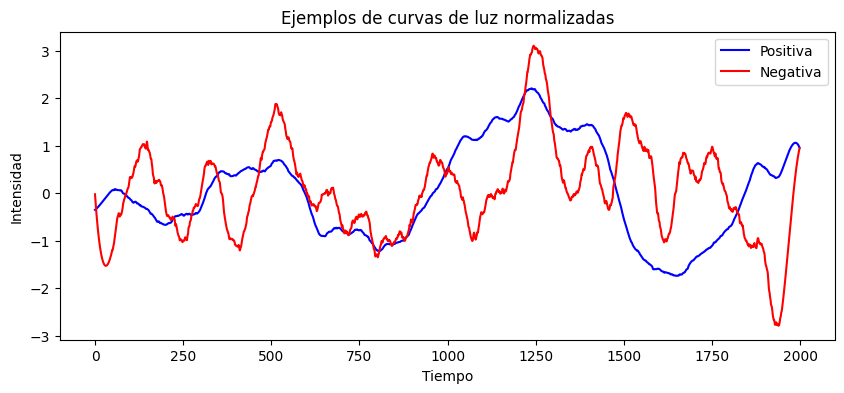

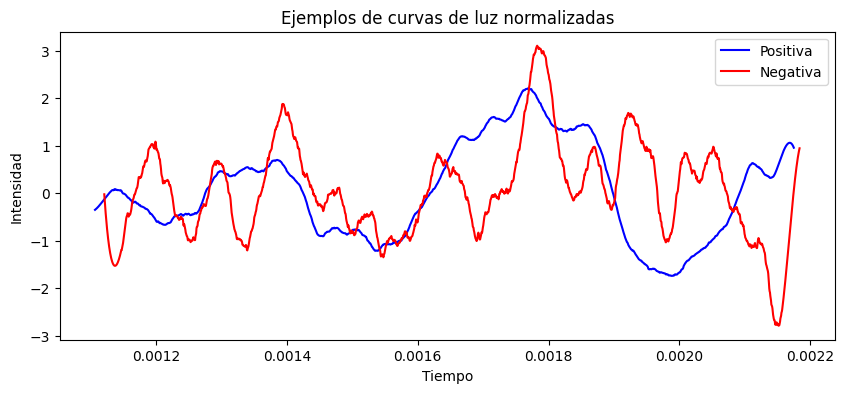

In [10]:
# Visualizar ejemplos
import matplotlib.pyplot as plt
import numpy as np

pos = np.load("../data/processed/train/positive/positive_0.npy")
neg = np.load("../data/processed/train/negative/negative_0.npy")


print("Pos shape:", pos.shape)
print("Neg shape:", neg.shape)

plt.figure(figsize=(10, 4))
plt.plot(pos[:, 1], label="Positiva", color="blue")
plt.plot(neg[:, 1], label="Negativa", color="red")
plt.legend()
plt.title("Ejemplos de curvas de luz normalizadas")
plt.xlabel("Tiempo")
plt.ylabel("Intensidad")
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(pos[:, 0], pos[:, 1], label="Positiva", color="blue")
plt.plot(neg[:, 0], neg[:, 1], label="Negativa", color="red")
plt.legend()
plt.title("Ejemplos de curvas de luz normalizadas")
plt.xlabel("Tiempo")
plt.ylabel("Intensidad")
plt.show()



In [1]:
import glob
import sys
import os
import torch
import tqdm
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from src.models.lightgbm_model import train_lightgbm_model
from src.models.cnn_model import evaluate_model, train_model

# ========================
# 2. Función para cargar curvas desde una carpeta (.npy)
# ========================
def load_light_curves(folder):
    curves = []
    files = glob.glob(os.path.join(folder, '*.npy'))
    for f in tqdm.tqdm(files, desc=f"Cargando {folder}"):
        data = np.load(f)            # Cargar archivo .npy
        flux = data[:, 1]            # Extraer solo la segunda columna (flux)
        curves.append(flux)
    return curves

# ========================
# 3. Cargar conjuntos train/val/test por separado
# ========================
def load_dataset_splitted(base_path):
    def cargar_conjunto(tipo):
        pos = load_light_curves(os.path.join(base_path, tipo, 'positive'))
        neg = load_light_curves(os.path.join(base_path, tipo, 'negative'))
        X = np.array(pos + neg)
        y = np.array([1]*len(pos) + [0]*len(neg))
        return X, y

    X_train, y_train = cargar_conjunto('train')
    X_val, y_val     = cargar_conjunto('val')
    X_test, y_test   = cargar_conjunto('test')

    return (X_train, y_train), (X_val, y_val), (X_test, y_test)

# ========================
# 4. Ejecutar entrenamiento CNN
# ========================
def run_cnn_and_get_metrics():
    (X_train, y_train), (X_val, y_val), (X_test, y_test) = load_dataset_splitted('../data/processed')
    
    # Concatenar train y val para entrenamiento con validación
    X_all = np.concatenate([X_train, X_val], axis=0)
    y_all = np.concatenate([y_train, y_val], axis=0)

    output_path = '../models/cnn_model.pt'
    os.makedirs(os.path.dirname(output_path), exist_ok=True)

    model, history, _ = train_model(X_all, y_all, epochs=50, batch_size=64, lr=1e-4, patience=15, output_path=output_path)

    # Evaluar con test
    test_data = (X_test, y_test)
    cnn_metrics = evaluate_model(model, test_data, output_dir='../reports/figures/CNN/')

    return cnn_metrics, history

# ========================
# 5. Ejecutar pipeline
# ========================
print("\nEntrenando CNN...")
cnn_metrics, history = run_cnn_and_get_metrics()
print("CNN Metrics:", cnn_metrics)

# === Graficar entrenamiento ===
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title("Pérdida")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['val_acc'], label='Val Acc')
plt.title("Precisión")
plt.legend()

plt.tight_layout()
plt.show()



Entrenando CNN...


Cargando ../data/processed\test\negative: 100%|██████████| 150/150 [00:00<00:00, 1454.36it/s]


Entrenando en: cpu
Training Simple CNN model (optimiz.) with augmentation = False


c:\Users\remon\OneDrive\Escritorio\exoplanet-ml-project\venv\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Shape de xb antes de model: torch.Size([64, 1999])


RuntimeError: Given groups=1, weight of size [32, 1, 5], expected input[1, 64, 1999] to have 1 channels, but got 64 channels instead

In [ ]:
import os
import numpy as np
import optuna
from sklearn.utils import shuffle

# Función para cargar todas las curvas desde una carpeta
def load_curves_from_folder(folder_path, label):
    curves = []
    labels = []
    for fname in os.listdir(folder_path):
        if fname.endswith(".npy"):
            curve = np.load(os.path.join(folder_path, fname))
            if len(curve.shape) == 2 and curve.shape[1] == 2:
                flux = curve[:, 1]  # seleccionar solo la columna de flux
            else:
                flux = curve  # ya es unidimensional
            curves.append(flux)
            labels.append(label)
    return curves, labels

# Cargar curvas positivas y negativas
pos_folder = '../data/processed/train/positive'
neg_folder = '../data/processed/train/negative'

X_pos, y_pos = load_curves_from_folder(pos_folder, label=1)
X_neg, y_neg = load_curves_from_folder(neg_folder, label=0)

# Convertir a arrays
X_pos = np.array(X_pos)
X_neg = np.array(X_neg)
y_pos = np.array(y_pos)
y_neg = np.array(y_neg)

# Balancear dataset
min_len = min(len(X_pos), len(X_neg))
X = np.concatenate([X_pos[:min_len], X_neg[:min_len]], axis=0)
y = np.concatenate([y_pos[:min_len], y_neg[:min_len]], axis=0)

# Mezclar
X, y = shuffle(X, y, random_state=42)

# Función objetivo para Optuna
def objective(trial):
    # Hiperparámetros sugeridos
    lr = trial.suggest_float("lr", 1e-5, 1e-3, log=True)
    batch_size = trial.suggest_categorical("batch_size", [32, 64, 128])
    lstm_hidden = trial.suggest_int("lstm_hidden", 64, 256, step=64)
    lstm_layers = trial.suggest_int("lstm_layers", 1, 3)
    dropout = trial.suggest_float("dropout", 0.2, 0.5)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)

    # Entrenar modelo
    model, history, test_set = train_model(
        X, y,
        epochs=50,
        batch_size=batch_size,
        lr=lr,
        patience=7,
        weight_decay=weight_decay,
        lstm_hidden=lstm_hidden,
        lstm_layers=lstm_layers,
        dropout=dropout,
        augment_noise=True,
        output_path=f"models/trial_model_{trial.number}.pt"
    )

    # Evaluar modelo
    metrics = evaluate_model(model, test_set, output_dir=f"eval_figures/trial_{trial.number}")
    
    return metrics["f1"]  # o "accuracy", "auc", etc.

# Ejecutar Optuna
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20)

# Mostrar mejores resultados
print("Mejores hiperparámetros:")
print(study.best_params)


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader, random_split
from torch.optim.lr_scheduler import ReduceLROnPlateau
import numpy as np
import os

# =========================
# 1. Modelo CNN 1D Simple
# =========================
class SimpleCNN1D(nn.Module):
    def __init__(self, dropout=0.3):
        super(SimpleCNN1D, self).__init__()
        self.conv1 = nn.Conv1d(1, 16, kernel_size=5, padding=2)
        self.bn1 = nn.BatchNorm1d(16)
        self.pool1 = nn.MaxPool1d(2)

        self.conv2 = nn.Conv1d(16, 32, kernel_size=5, padding=2)
        self.bn2 = nn.BatchNorm1d(32)
        self.pool2 = nn.MaxPool1d(2)

        # Calcular automáticamente flatten_dim
        with torch.no_grad():
            dummy_input = torch.zeros(1, 1, 200)
            x = self.pool1(F.relu(self.bn1(self.conv1(dummy_input))))
            x = self.pool2(F.relu(self.bn2(self.conv2(x))))
            self.flatten_dim = x.view(1, -1).shape[1]

        self.fc1 = nn.Linear(self.flatten_dim, 64)
        self.dropout = nn.Dropout(dropout)
        self.fc2 = nn.Linear(64, 1)

    def forward(self, x):
        x = self.pool1(F.relu(self.bn1(self.conv1(x))))
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        return torch.sigmoid(self.fc2(x))

# =========================
# 2. Función de entrenamiento
# =========================
def train_model(X, y, output_path='cnn_model.pt', epochs=50, batch_size=64, lr=1e-4, patience=10, dropout=0.3):

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Entrenando en: {device}")

    model = SimpleCNN1D(dropout=dropout).to(device)

    # Asegurar que input tenga canal: (N, 1, 200)
    X_tensor = torch.tensor(X, dtype=torch.float32)
    if X_tensor.ndim == 2:
        X_tensor = X_tensor.unsqueeze(1)  # (N, 1, 200)

    y_tensor = torch.tensor(y, dtype=torch.float32).unsqueeze(1)
    dataset = TensorDataset(X_tensor, y_tensor)

    train_len = int(0.7 * len(dataset))
    val_len = int(0.15 * len(dataset))
    test_len = len(dataset) - train_len - val_len
    train_set, val_set, test_set = random_split(dataset, [train_len, val_len, test_len])

    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)
    val_loader = DataLoader(val_set, batch_size=batch_size, num_workers=4, pin_memory=True)

    criterion = nn.BCELoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

    best_loss = float('inf')
    counter = 0
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(epochs):
        model.train()
        train_loss, correct = 0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            loss = criterion(pred, yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * xb.size(0)
            correct += ((pred > 0.5) == yb).sum().item()

        train_loss /= len(train_loader.dataset)
        train_acc = correct / len(train_loader.dataset)

        # Validación
        model.eval()
        val_loss, val_correct = 0, 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                pred = model(xb)
                loss = criterion(pred, yb)
                val_loss += loss.item() * xb.size(0)
                val_correct += ((pred > 0.5) == yb).sum().item()

        val_loss /= len(val_loader.dataset)
        val_acc = val_correct / len(val_loader.dataset)

        scheduler.step(val_loss)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        print(f"Epoch {epoch+1}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}, "
              f"train_acc={train_acc:.4f}, val_acc={val_acc:.4f}")

        if val_loss < best_loss:
            best_loss = val_loss
            counter = 0
            torch.save(model.state_dict(), output_path)
        else:
            counter += 1
            if counter >= patience:
                print("Early stopping.")
                break

    return model, history, test_set





Entrenando modelo CNN...


Cargando ../data/processed\test\negative: 100%|██████████| 150/150 [00:00<00:00, 2194.93it/s]


Entrenando en: cpu
Training Simple CNN model (optimiz.) with augmentation = False
Shape de xb antes de model: torch.Size([64, 200])


RuntimeError: Given groups=1, weight of size [32, 1, 5], expected input[1, 64, 200] to have 1 channels, but got 64 channels instead